# Using Machine Learning to predict Ontario Housing Prices

| Alec De Sousa | Hermes Hui | 
| :---: | :---: |
| 500918882 |  500763595 |
| alec.desousa@torontomu.ca | hchui@torontomu.ca |

In [6]:
# Import libraries and read cleaned data

import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from mlxtend.frequent_patterns import apriori, association_rules
import shap

data = pd.read_csv("data_on - Shortened.csv")

### Clustering

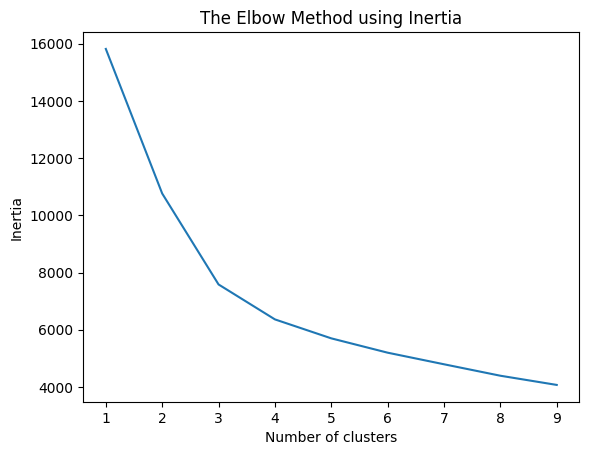

Silhouette score for k = 3: 0.4052272882322964
From the above graph and silhouette score, k = 3 is the most optimal value for k.

+-----------------+
| Cluster by mean |
+-----------------+
                price  property-beds  property-baths  property-sqft      Bath  \
cluster                                                                         
0        3.921716e+05       3.144404        1.707581    1318.411552  0.000000   
1        7.438869e+05       3.132867        2.733489    1677.662782  1.038850   
2        2.059095e+06       4.797136        4.372315    3742.310263  1.164678   

         Partial Bathroom  price-per-sqft  
cluster                                    
0                0.000000      298.534277  
1                1.038850      451.852143  
2                1.164678      565.722547  

+-------------------+
| Cluster by median |
+-------------------+
             price  property-beds  property-baths  property-sqft  Bath  \
cluster                                    

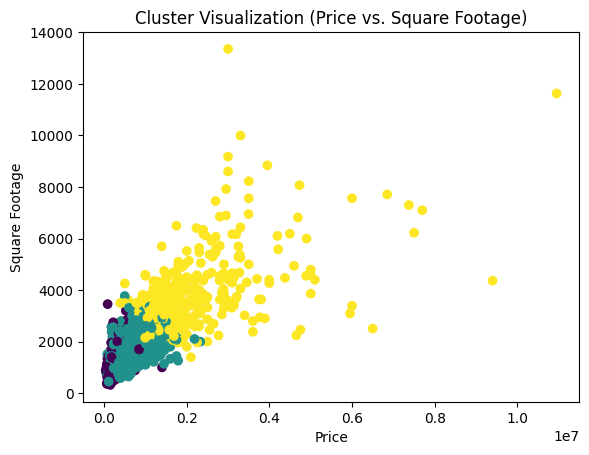

Cluster 0: This cluster represents the cheapest houses (average of ~$390K), with the least square footage (average of ~1300 sqft).
 That said, these houses average at ~3 bedrooms, which fufills our goal of finding a home for a family with a young child.

Cluster 1: This cluster represents more mid-range homes (average of ~$740K), with a little more average square footage than cluster 0 (~1700 sqft).
 On average, these houses have the same number of bedrooms as cluster 0, but have one more bathroom which may also include a bathtub.
 These aspects may make cluster 1 more attractive to our family.

Cluster 2: This cluster represents large, higher-end homes (average of ~$2.05M and ~3700 sqft).
 On average, these homes contain 4-5 bedrooms, 4 bathrooms, and 1 bathtub.
 Assuming our family is middle-class, these homes would likely be out of their price range.
 Beyond that, 4-5 bedrooms would be unnecessary for a family of 3.


In [7]:
# Clustering only works with numerical data, so only read numeric attributes
# That said, having the square footage of the house would be nice, but it's in string format, so must convert it
data["property-sqft"] = (
    data["property-sqft"]
    .astype(str)                # Ensure data is a string
    .str.replace("sqft", "")    # Remove the "sqft" text
    .str.replace(",", "")       # Remove commas
    .str.replace(" ", "")       # Remove any spaces
)

# Conversion from string to numeric
data["property-sqft"] = pd.to_numeric(data["property-sqft"])

# Now that we have sqft in numeric, we can take the oppurtunity to create a price per sqft attribute
data["price-per-sqft"] = data["price"] / data["property-sqft"]

# Now that everything we want is in numerical format, we can continue
data_numeric = data.select_dtypes(include=["int64","float64"])
data_numeric = data_numeric.dropna() # Handling missing values

# After some analysis, the most expensive house in the dataset is more than double the price of the 2nd most expensive.
# Removing that outlier here:
outlier = data_numeric["price"].idxmax()
data_numeric = data_numeric.drop(index = outlier)

# Using StandardScaler from the scikit-learn library to scale the data (very important for clustering)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(data_numeric)

# Now that the data is scaled, we can apply K-means clustering. We must first figure out what our K should be.
# Using the elbow method [https://www.geeksforgeeks.org/machine-learning/elbow-method-for-optimal-value-of-k-in-kmeans/], we can
# Create a graph using the matplotlib library in order to find the "elbow" of the graph. This tells us what the optimal K should be.
inertia = []

for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, random_state=11, n_init = 10) # As long as random_state is the same, the results will be reproducible
                                                                # Also, n_init is how many times K-means runs, choosing the best (in this case, 10 runs)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(range(1, 10), inertia)
plt.title("The Elbow Method using Inertia")
plt.xlabel("Number of clusters")
plt.ylabel("Inertia")
plt.show()

# The graph shows that the optimal k is likely either 3 or 4. After calculating the silhouette score for both, the results were:
# k = 3: 0.40522728823163784
# k = 4: 0.3558610079334486
# k = 3 is a higher value, and therefore more optimal

# Now that we have the optimal k value (k = 3), we can apply K-means clustering using scikit-learn library
kmeans = KMeans(n_clusters = 3, random_state = 11, n_init = 10)
kmeans.fit(X_scaled)

data_numeric["cluster"] = kmeans.labels_

# From the graph, k = 3 seems to be optimal. But to be sure, we'll check using the scikit-learn library's silhouette score function
score = silhouette_score(X_scaled, data_numeric["cluster"])
print("Silhouette score for k = 3:", score)
print("From the above graph and silhouette score, k = 3 is the most optimal value for k.")

print("\n+-----------------+")
print("| Cluster by mean |")
print("+-----------------+")
print(data_numeric.groupby("cluster").mean())
print("\n+-------------------+")
print("| Cluster by median |")
print("+-------------------+")
print(data_numeric.groupby("cluster").median())
print("\n")

# Create a graph to visualize the clusters we just found
plt.scatter(data_numeric["price"], data_numeric["property-sqft"], c=data_numeric["cluster"])
plt.title("Cluster Visualization (Price vs. Square Footage)")
plt.xlabel("Price")
plt.ylabel("Square Footage")
plt.show()

# Interpreting the results:
print("Cluster 0: This cluster represents the cheapest houses (average of ~$390K), with the least square footage (average of ~1300 sqft).\n",
     "That said, these houses average at ~3 bedrooms, which fufills our goal of finding a home for a family with a young child.")

print("\nCluster 1: This cluster represents more mid-range homes (average of ~$740K), with a little more average square footage than cluster 0 (~1700 sqft).\n",
     "On average, these houses have the same number of bedrooms as cluster 0, but have one more bathroom which may also include a bathtub.\n",
     "These aspects may make cluster 1 more attractive to our family.")

print("\nCluster 2: This cluster represents large, higher-end homes (average of ~$2.05M and ~3700 sqft).\n",
      "On average, these homes contain 4-5 bedrooms, 4 bathrooms, and 1 bathtub.\n",
      "Assuming our family is middle-class, these homes would likely be out of their price range.\n",
      "Beyond that, 4-5 bedrooms would be unnecessary for a family of 3.")


#### Association Rules

In [ ]:
# Creating categories for the numeric attributes
# Price, beds, bathrooms, bathtubs, partial bathrooms, price-per-sqft 
data["price-categories"] = pd.cut(data["price"], bins = 3, labels = ["low", "mid", "high"])
data["beds-categories"] = pd.cut(data["property-beds"], bins = [-1, 2, 4, 10], labels = ["low", "mid", "high"]) # 0-2 = low, 3-4 = mid, 5-10 = high
data["bathrooms-categories"] = pd.cut(data["property-baths"], bins = [-1, 1, 3, 10], labels = ["low", "mid", "high"]) # 0-1 = low, 2-3 = mid, 3-10 = high
data["sqft-categories"] = pd.cut(data["property-sqft"], bins = 3, labels = ["low", "mid", "high"])
data["bathtubs-categories"] = pd.cut(data["Bath"], bins = [-1, 1, 2, 10], labels = ["low", "mid", "high"]) # 0-1 = low, 2 = mid, 3-10 = high
data["partial-bathrooms-categories"] = pd.cut(data["Partial Bathroom"], bins = [-1, 1, 3, 10], labels = ["low", "mid", "high"]) # 0-1 = low, 2-3 = mid, 4-10 = high
data["price-per-sqft-categories"] = pd.cut(data["price-per-sqft"], bins = 3, labels = ["low", "mid", "high"])

# Including the clusters made earlier, and converting it into a string
data["cluster"] = data_numeric["cluster"]
data["cluster"] = data["cluster"].astype(str)

# Additionally, adding addressLocality. That said, addressLocality isn't suitable for association rules by itself (too many options with sparse data,
# which translates to very weak rules). To circumvent this issue, we find the top 10 most common localities, and group everything else into "other".
# This will avoid sparse data, while keeping meaningful locations to make associations with.

# Before that, however, we will clean the data to merge things like "Thunder Bay" and "THUNDER BAY", or "Ajax (Central East)" and "Ajax (Central West)"
data["addressLocality"] = (
    data["addressLocality"]
        .str.lower()                               # Turns everything lowercase
        .str.replace(r"\(.*?\)", "", regex = True) # Remove brackets and what's inside them
        .str.strip()                               # Removes white space at the beginning and end of the data
        .str.title()                               # Capitalizes the first letter to enhance readability
)

# Now, we can group the localities
top_localities = data["addressLocality"].value_counts().nlargest(10).index # Finding the top 10 localities
data["locality-group"] = data["addressLocality"].apply(lambda x: x if x in top_localities else "Other") # If data isn't in top localities, group into "Other"

# OK, now we can find the association rules
data_rules = data[[
    "price-categories",
    "beds-categories",
    "bathrooms-categories",
    "sqft-categories",
    "bathtubs-categories",
    "partial-bathrooms-categories",
    "price-per-sqft-categories",
    "cluster",
    "locality-group"
    ]]

# Encoding the categorical attributes
data_encoded = pd.get_dummies(data_rules)

# Using mlxtend library to run apriori, then generating the association rules
frequent_itemsets = apriori(data_encoded, min_support = 0.2, use_colnames = True)
rules = association_rules(frequent_itemsets, metric = "confidence", min_threshold = 0.8)

# Turns support (percentage of the dataset) into support_count (total numbers)
rules["support_count"] = rules["support"] * len(data_encoded)

# Sort by confidence in descending order, and show top 10 rules
top_rules = rules.sort_values(by = "confidence", ascending = False).head(10)

# Printing the rules as a string for readability
rule_strings = []
print("10 Association Rules:")

for _, row in top_rules.iterrows():
    antecedent = ", ".join(list(row["antecedents"]))
    consequent = ", ".join(list(row["consequents"]))
    support = int(row["support_count"])
    confidence = row["confidence"]

    rule_str = f"IF {antecedent} THEN {consequent} (support_count = {support}, confidence={confidence:.2f})"
    rule_strings.append(rule_str)

for r in rule_strings:
    print(r)


10 Association Rules:
IF price-categories_low, partial-bathrooms-categories_low THEN bathtubs-categories_low (support_count = 11901, confidence=1.00)
IF price-categories_low, bathtubs-categories_low THEN partial-bathrooms-categories_low (support_count = 11901, confidence=1.00)
IF partial-bathrooms-categories_low THEN price-categories_low, bathtubs-categories_low (support_count = 11901, confidence=1.00)
IF bathtubs-categories_low THEN price-categories_low, partial-bathrooms-categories_low (support_count = 11901, confidence=1.00)
IF partial-bathrooms-categories_low, beds-categories_mid THEN bathtubs-categories_low (support_count = 7277, confidence=1.00)
IF bathtubs-categories_low, beds-categories_mid THEN partial-bathrooms-categories_low (support_count = 7277, confidence=1.00)
IF partial-bathrooms-categories_low, bathrooms-categories_mid THEN bathtubs-categories_low (support_count = 6633, confidence=1.00)
IF bathtubs-categories_low, bathrooms-categories_mid THEN partial-bathrooms-categor

## Decision Tree

|--- bathrooms-categories_high <= 0.50
|   |--- bathrooms-categories_low <= 0.50
|   |   |--- locality-group_Other <= 0.50
|   |   |   |--- beds-categories_high <= 0.50
|   |   |   |   |--- locality-group_Oakville <= 0.50
|   |   |   |   |   |--- locality-group_Kitchener <= 0.50
|   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |--- locality-group_Kitchener >  0.50
|   |   |   |   |   |   |--- beds-categories_mid <= 0.50
|   |   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |   |--- beds-categories_mid >  0.50
|   |   |   |   |   |   |   |--- bathtubs-categories_mid <= 0.50
|   |   |   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |   |   |--- bathtubs-categories_mid >  0.50
|   |   |   |   |   |   |   |   |--- class: 1
|   |   |   |   |--- locality-group_Oakville >  0.50
|   |   |   |   |   |--- beds-categories_mid <= 0.50
|   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |--- beds-categories_mid >  0.50
|   |   |   |   |   |   |--- class: 1
|   |   |  

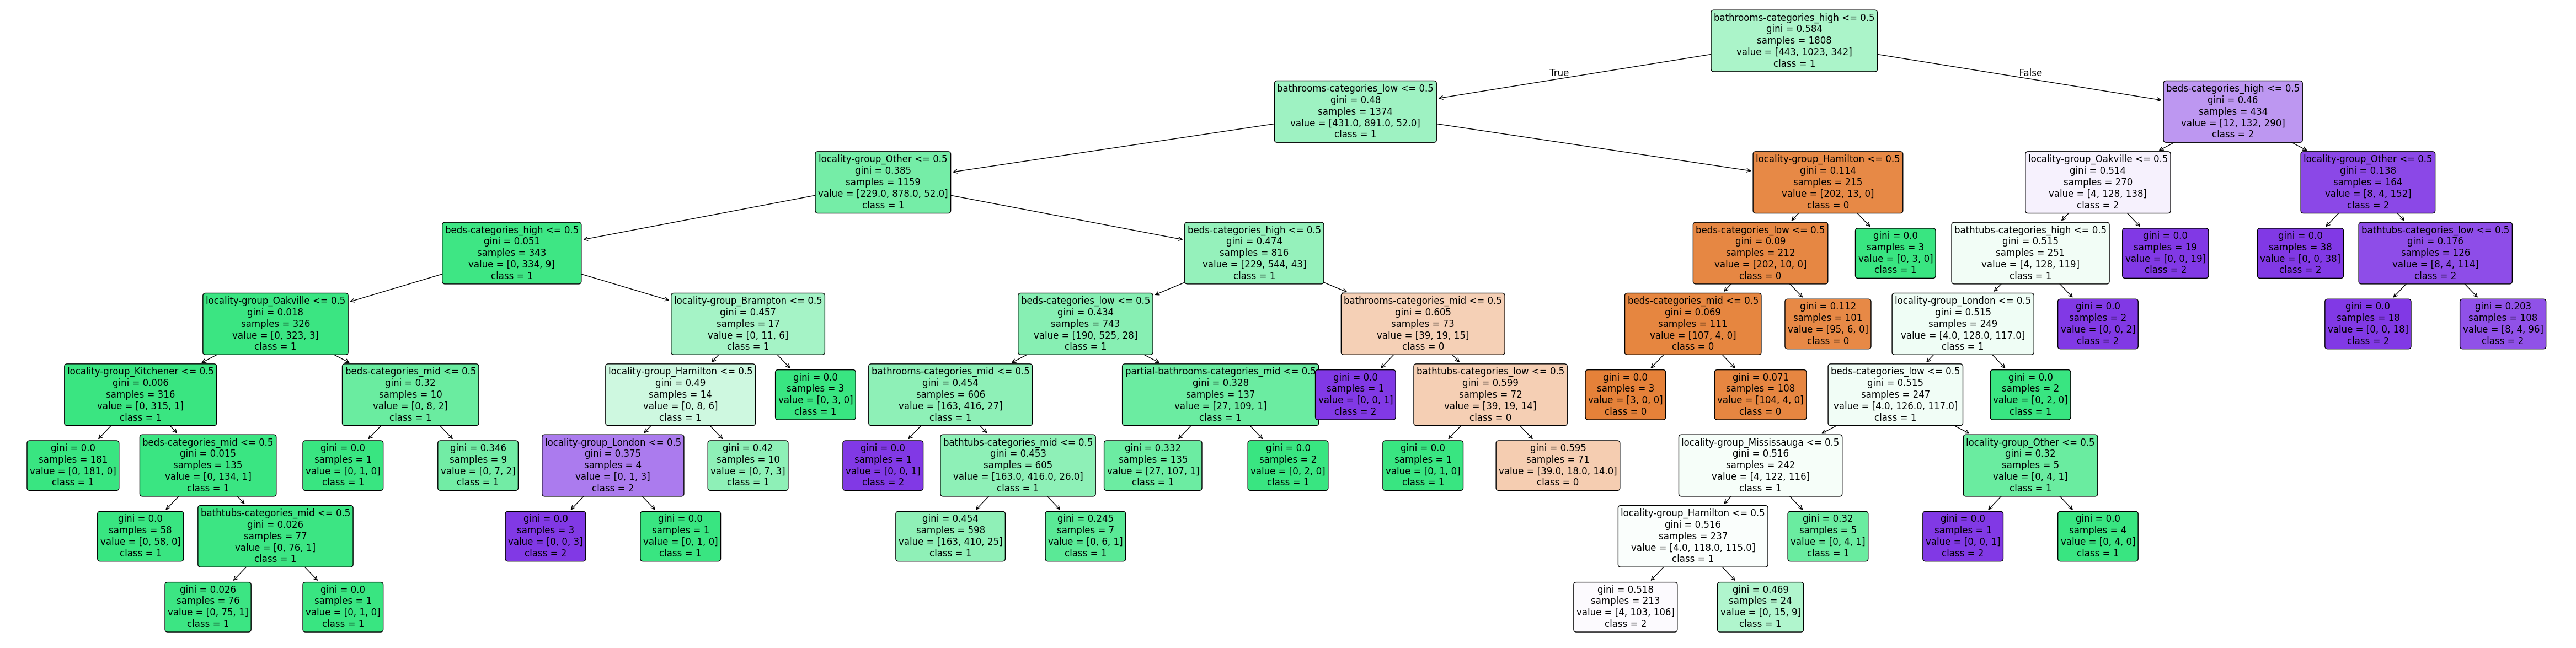

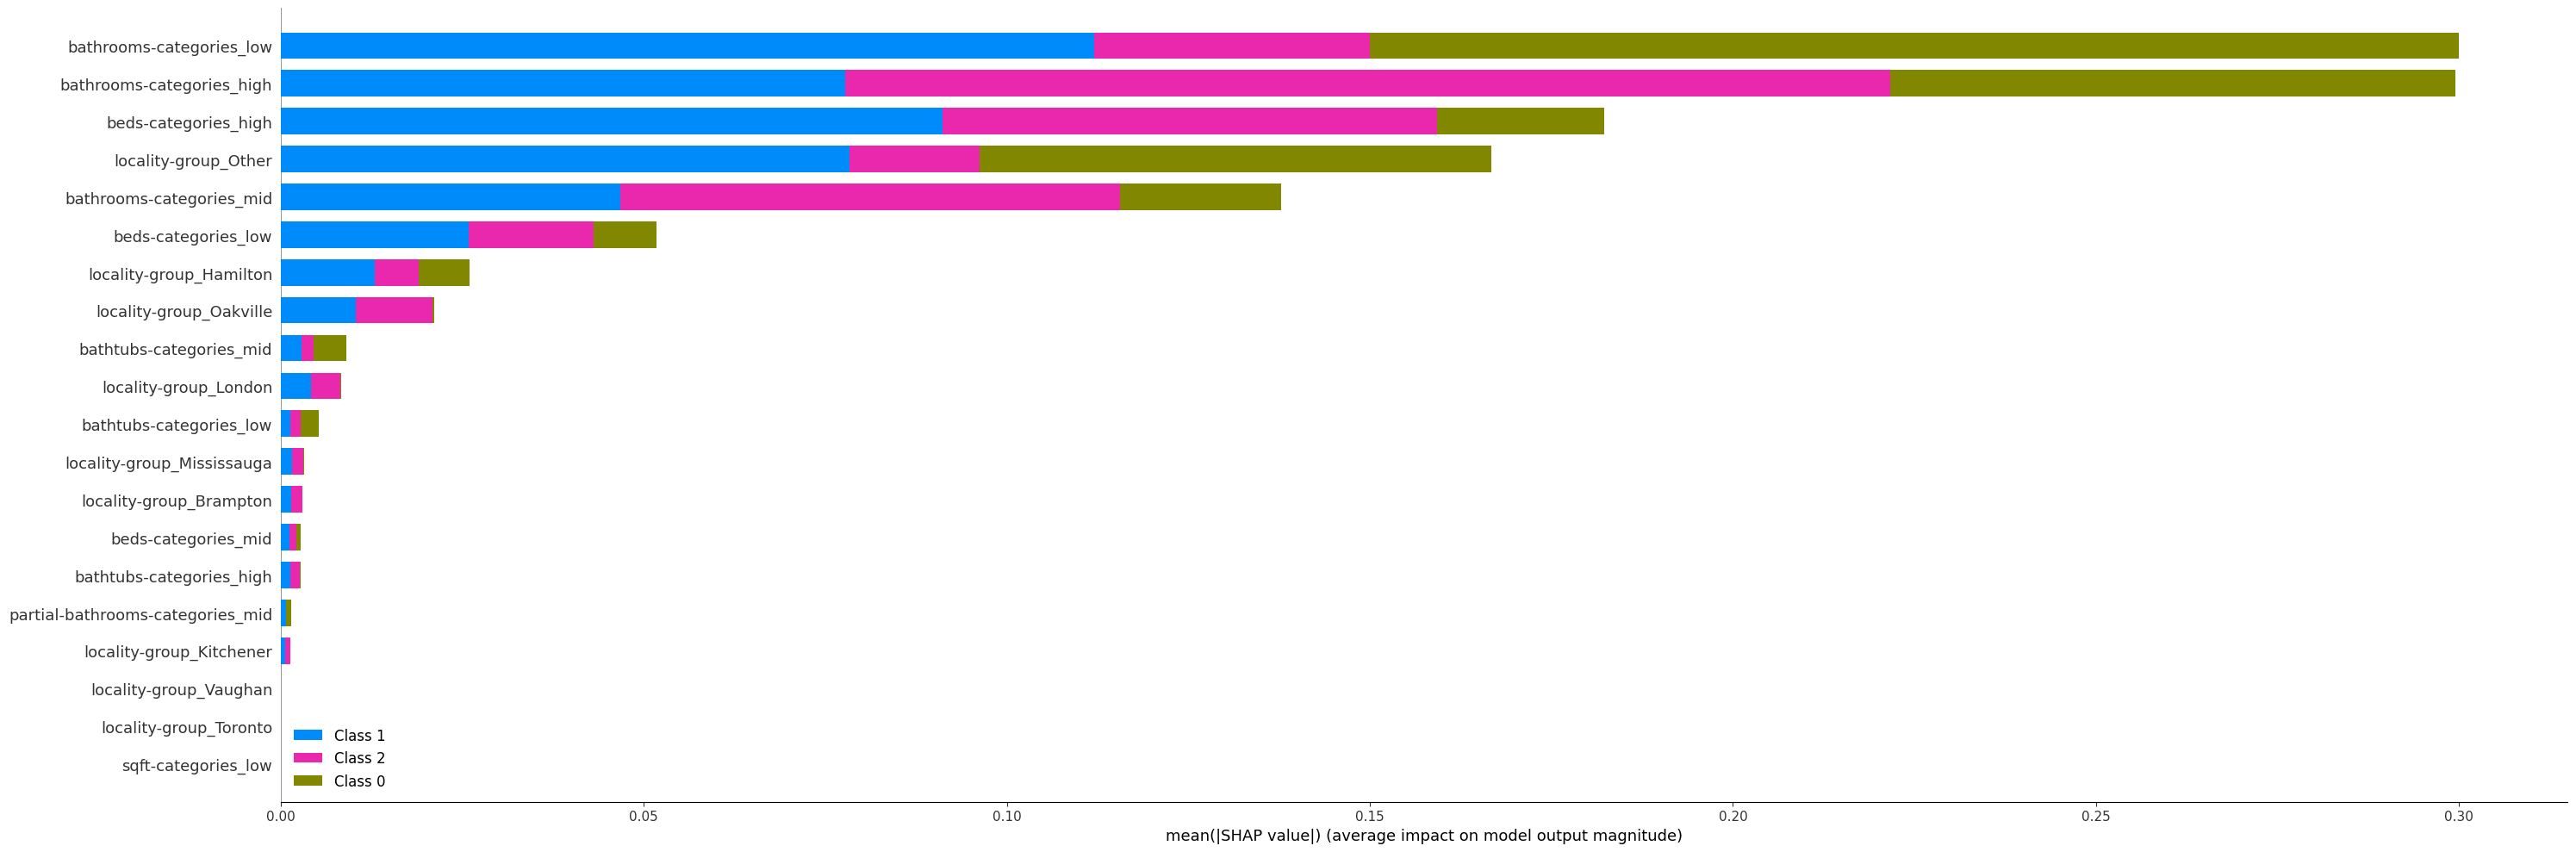

In [28]:
# Remove NaNs if any from dataset
data_dtree = data.dropna(subset = ['cluster'])
feature_cols = ['locality-group', 'beds-categories', 'bathrooms-categories',
                 'sqft-categories', 'bathtubs-categories', 'partial-bathrooms-categories']
X_dtree = pd.get_dummies(data_dtree[feature_cols])
y_dtree = data_dtree['cluster'].astype(float).astype(int)

# Split Training and Test Datasets
X_train, X_test, y_train, y_test = train_test_split(X_dtree, y_dtree, test_size = 0.2, random_state = 42)

# Create and Train Decision Tree
dtree_model = DecisionTreeClassifier(max_depth = 8, random_state = 42)
dtree_model.fit(X_train, y_train)

# Extract and print Decision Tree Rules
dtree_rules = export_text(dtree_model, feature_names = list(X_dtree.columns))
print(dtree_rules)

# Visualize the Decision Tree
plt.figure(figsize = (60, 15))
plot_tree(dtree_model, feature_names = X_dtree.columns, class_names = [str(c) for c in dtree_model.classes_], filled = True, rounded = True, fontsize = 12)
plt.show()

# Conduct SHAP analysis on Decision Tree
shap_explainer = shap.TreeExplainer(dtree_model)
shap_values = shap_explainer.shap_values(X_test)

# Visual SHAP results
shap.summary_plot(shap_values, X_test, plot_type = 'bar', plot_size = (30, 10))